In [1]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_case_data_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(4950, 8)


In [2]:
import re
def case_name_split(case_name_list):
    pattern = r'(\w+)k-(\w+)seg-(\w+)'
    case_name_split_list = []
    for case_name in case_name_list:
        match = re.match(pattern, case_name)
        if match:
            case_split = match.groups()
            case_split = [int(case_split[0])*1000, int(case_split[1]), case_split[2]]
            case_name_split_list.append(case_split)
        else:
            print(f"Pattern not matched for {case_name}")
    return case_name_split_list

case_name_list = data['case_name']
case_name_split_list = case_name_split(case_name_list)
case_data = pd.DataFrame(case_name_split_list, columns=['ts_len', 'seg', 'seg_type'])
# merge the new columns with the original data
data_new = pd.concat([data, case_data], axis=1)
print(data_new.shape)

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    '20L', '20H', '50L', '50H', '100L', '100H', '500L', '500H',
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx


print(data_new.head())
print(data_new.columns)

(4950, 11)
          case_name model_name  case_seed metric_name  mean_val   std_val  \
0  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
1  100k-100seg-100H    Model10         53     AUC-ROC  0.100225  0.002738   
2  100k-100seg-100H    Model10         53      Aff-F1  0.599683  0.008507   
3  100k-100seg-100H    Model10         53          F1  0.007339  0.000856   
4  100k-100seg-100H    Model10         53       F1-PA  0.511857  0.041889   

   mean_latency  std_latency  ts_len  seg seg_type  
0     21.221560     0.059661  100000  100     100H  
1     28.568022     0.162600  100000  100     100H  
2    808.004104     2.556749  100000  100     100H  
3     38.742157     0.227650  100000  100     100H  
4     99.825350     0.573268  100000  100     100H  
Index(['case_name', 'model_name', 'case_seed', 'metric_name', 'mean_val',
       'std_val', 'mean_latency', 'std_latency', 'ts_len', 'seg', 'seg_type'],
      dtype='object')


In [3]:
# todo
# import matplotlib.pyplot as plt
# import seaborn as sns
# # 1. 相同长度下，不同指标的latency分布图
# def plot_latency_distribution(data, ts_len):
    

#     filtered_data = data[data['ts_len'] == ts_len]
#     metric_names = filtered_data['metric_name'].unique()
#     for metric in metric_names:
#         metric_data = filtered_data[filtered_data['metric_name'] == metric]
#         metric_data = metric_data.sort_values(by=['seg_type'], key=lambda x: x.apply(sort_seg_type_key))
#         # metric_latency = metric_data['mean_latency']
#         plt.figure(figsize=(4, 6))
#         sns.boxplot(x='seg_type', y='mean_latency', data=metric_data)
#         plt.title(f'Latency Distribution for ts_len = {ts_len}, Metric = {metric}')
#         plt.xlabel('Segment Type')
#         plt.ylabel('Latency')
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

# plot_latency_distribution(data_new, 10000)  # Example for ts_len = 1000


In [4]:
import matplotlib.font_manager as fm

# List all available fonts
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
for font in font_list:
    print(font)


/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf
/usr/share/fonts/opentype/urw-base35/NimbusSans-Bold.otf
/usr/share/fonts/truetype/tlwg/Loma-BoldOblique.ttf
/usr/share/fonts/truetype/tlwg/Garuda.ttf
/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed.ttf
/usr/share/fonts/truetype/freefont/FreeMonoOblique.ttf
/usr/share/fonts/truetype/fonts-gujr-extra/padmaa.ttf
/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf
/usr/share/fonts/opentype/urw-base35/P052-Italic.otf
/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-Regular.otf
/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed-BoldOblique.ttf
/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf
/usr/share/fonts/truetype/fonts-yrsa-rasa/Rasa-Light.ttf
/usr/share/fonts/opentype/urw-base35/P052-Bold.otf
/usr/share/fonts/truetype/tlwg/Norasi-BoldOblique.ttf
/usr/share/fonts/truetype/lohit-punjabi/Lohit-Gurmukhi.ttf
/usr/share/fonts/opentype/urw-base35/NimbusRoman-BoldItalic.otf
/usr/share/fonts/truetype/tl

/tmp/ipykernel_3914103/179052625.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric   Avg. Latency   Std. Latency  Avg. Latency per point
0           F1      50.445344      32.326455                0.000504
1        F1-PA     118.216156      61.411103                0.001182
2   Reduced-F1     128.929515      52.154205                0.001289
3         PA%K   10315.054153    2428.095533                0.103151
4   R-based F1     454.114204     201.633629                0.004541
5         TaPR    5348.283340    7381.321198                0.053483
6        eTaPR    3671.713591    4906.464507                0.036717
7       Aff-F1    1016.632151    1304.230550                0.010166
8      NAff-F1     998.830689    1212.913380                0.009988
9      UAff-F1     993.696537    1178.238137                0.009937
10        PATE  211306.594734  236827.981568                2.113066
11     AUC-ROC      41.481149      37.958252                0.000415
12      AUC-PR      26.043686      17.481738                0.000260
13     VUS-ROC   22240.809520   23

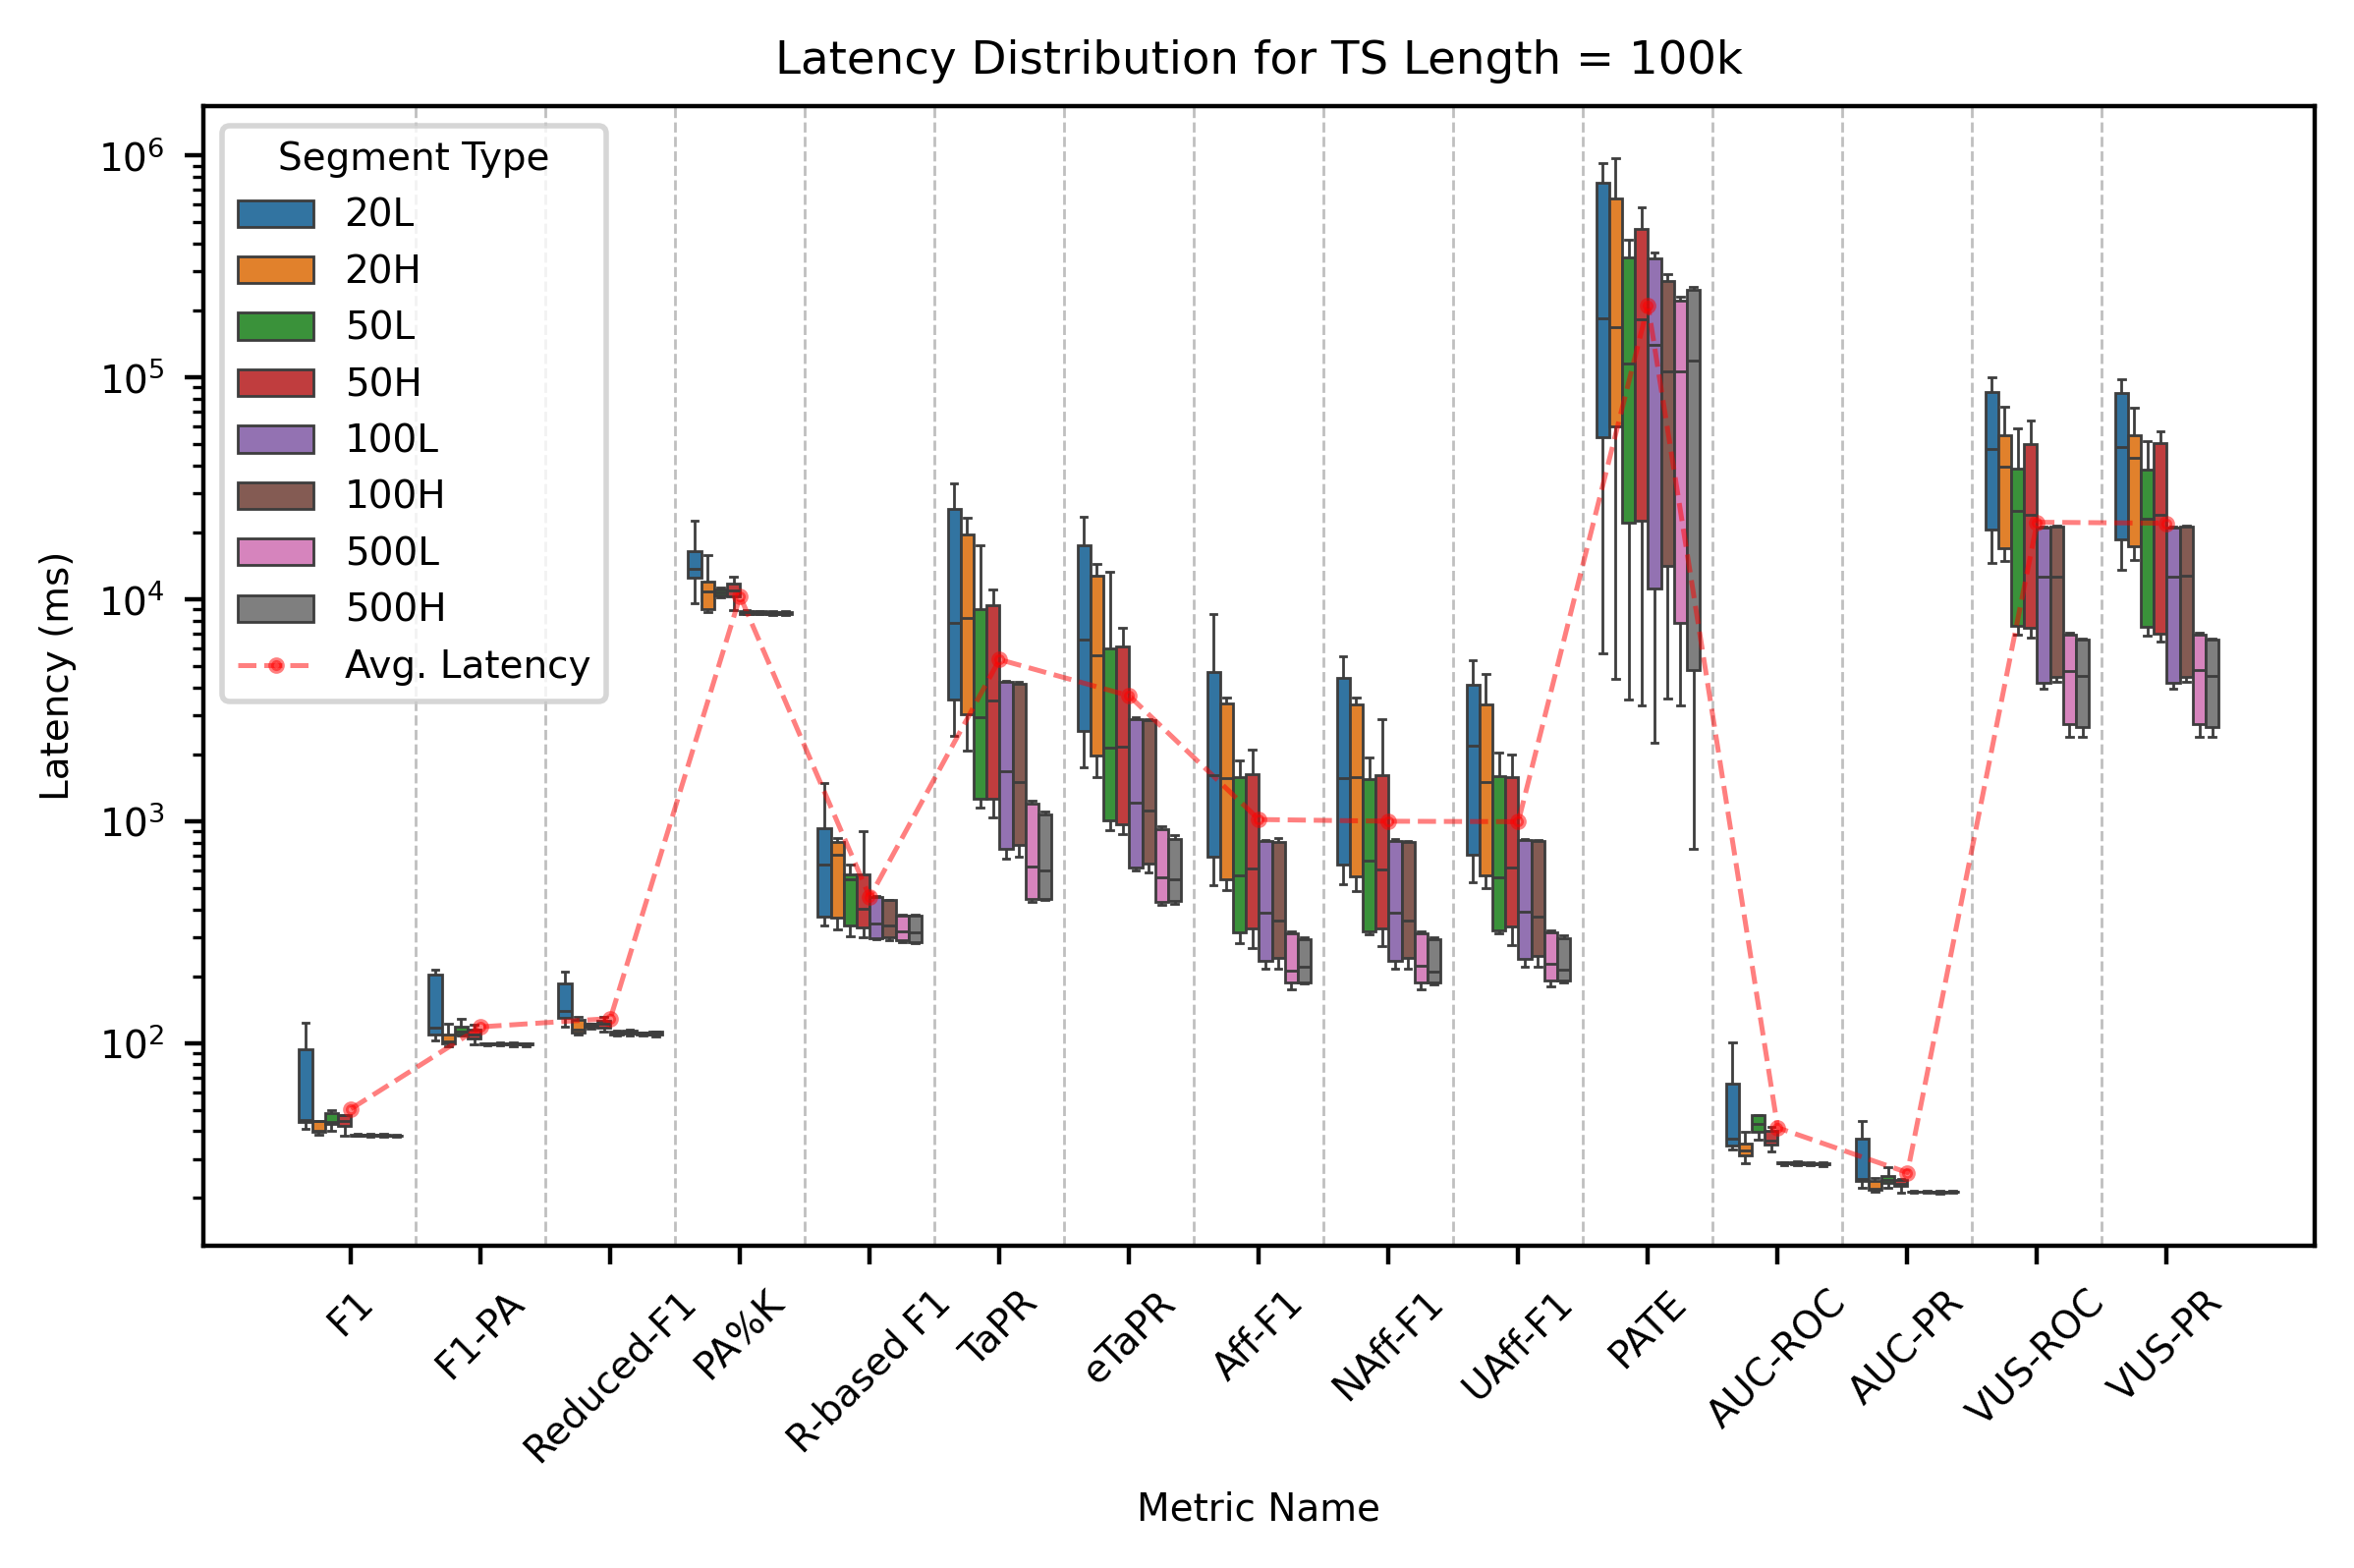

/tmp/ipykernel_3914103/179052625.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric  Avg. Latency  Std. Latency  Avg. Latency per point
0           F1      4.042186      0.038447                0.000404
1        F1-PA     10.488077      0.945121                0.001049
2   Reduced-F1     11.420450      0.348480                0.001142
3         PA%K    913.390437     13.014692                0.091339
4   R-based F1     31.504268      2.777392                0.003150
5         TaPR     84.678650     61.596868                0.008468
6        eTaPR     68.882082     39.232338                0.006888
7       Aff-F1     25.916985     10.844157                0.002592
8      NAff-F1     25.913158     10.820060                0.002591
9      UAff-F1     26.201554     10.811726                0.002620
10        PATE   3219.267488   2777.735057                0.321927
11     AUC-ROC      3.753863      1.193389                0.000375
12      AUC-PR      2.252767      0.066134                0.000225
13     VUS-ROC   1985.278049   1822.608941                0.19

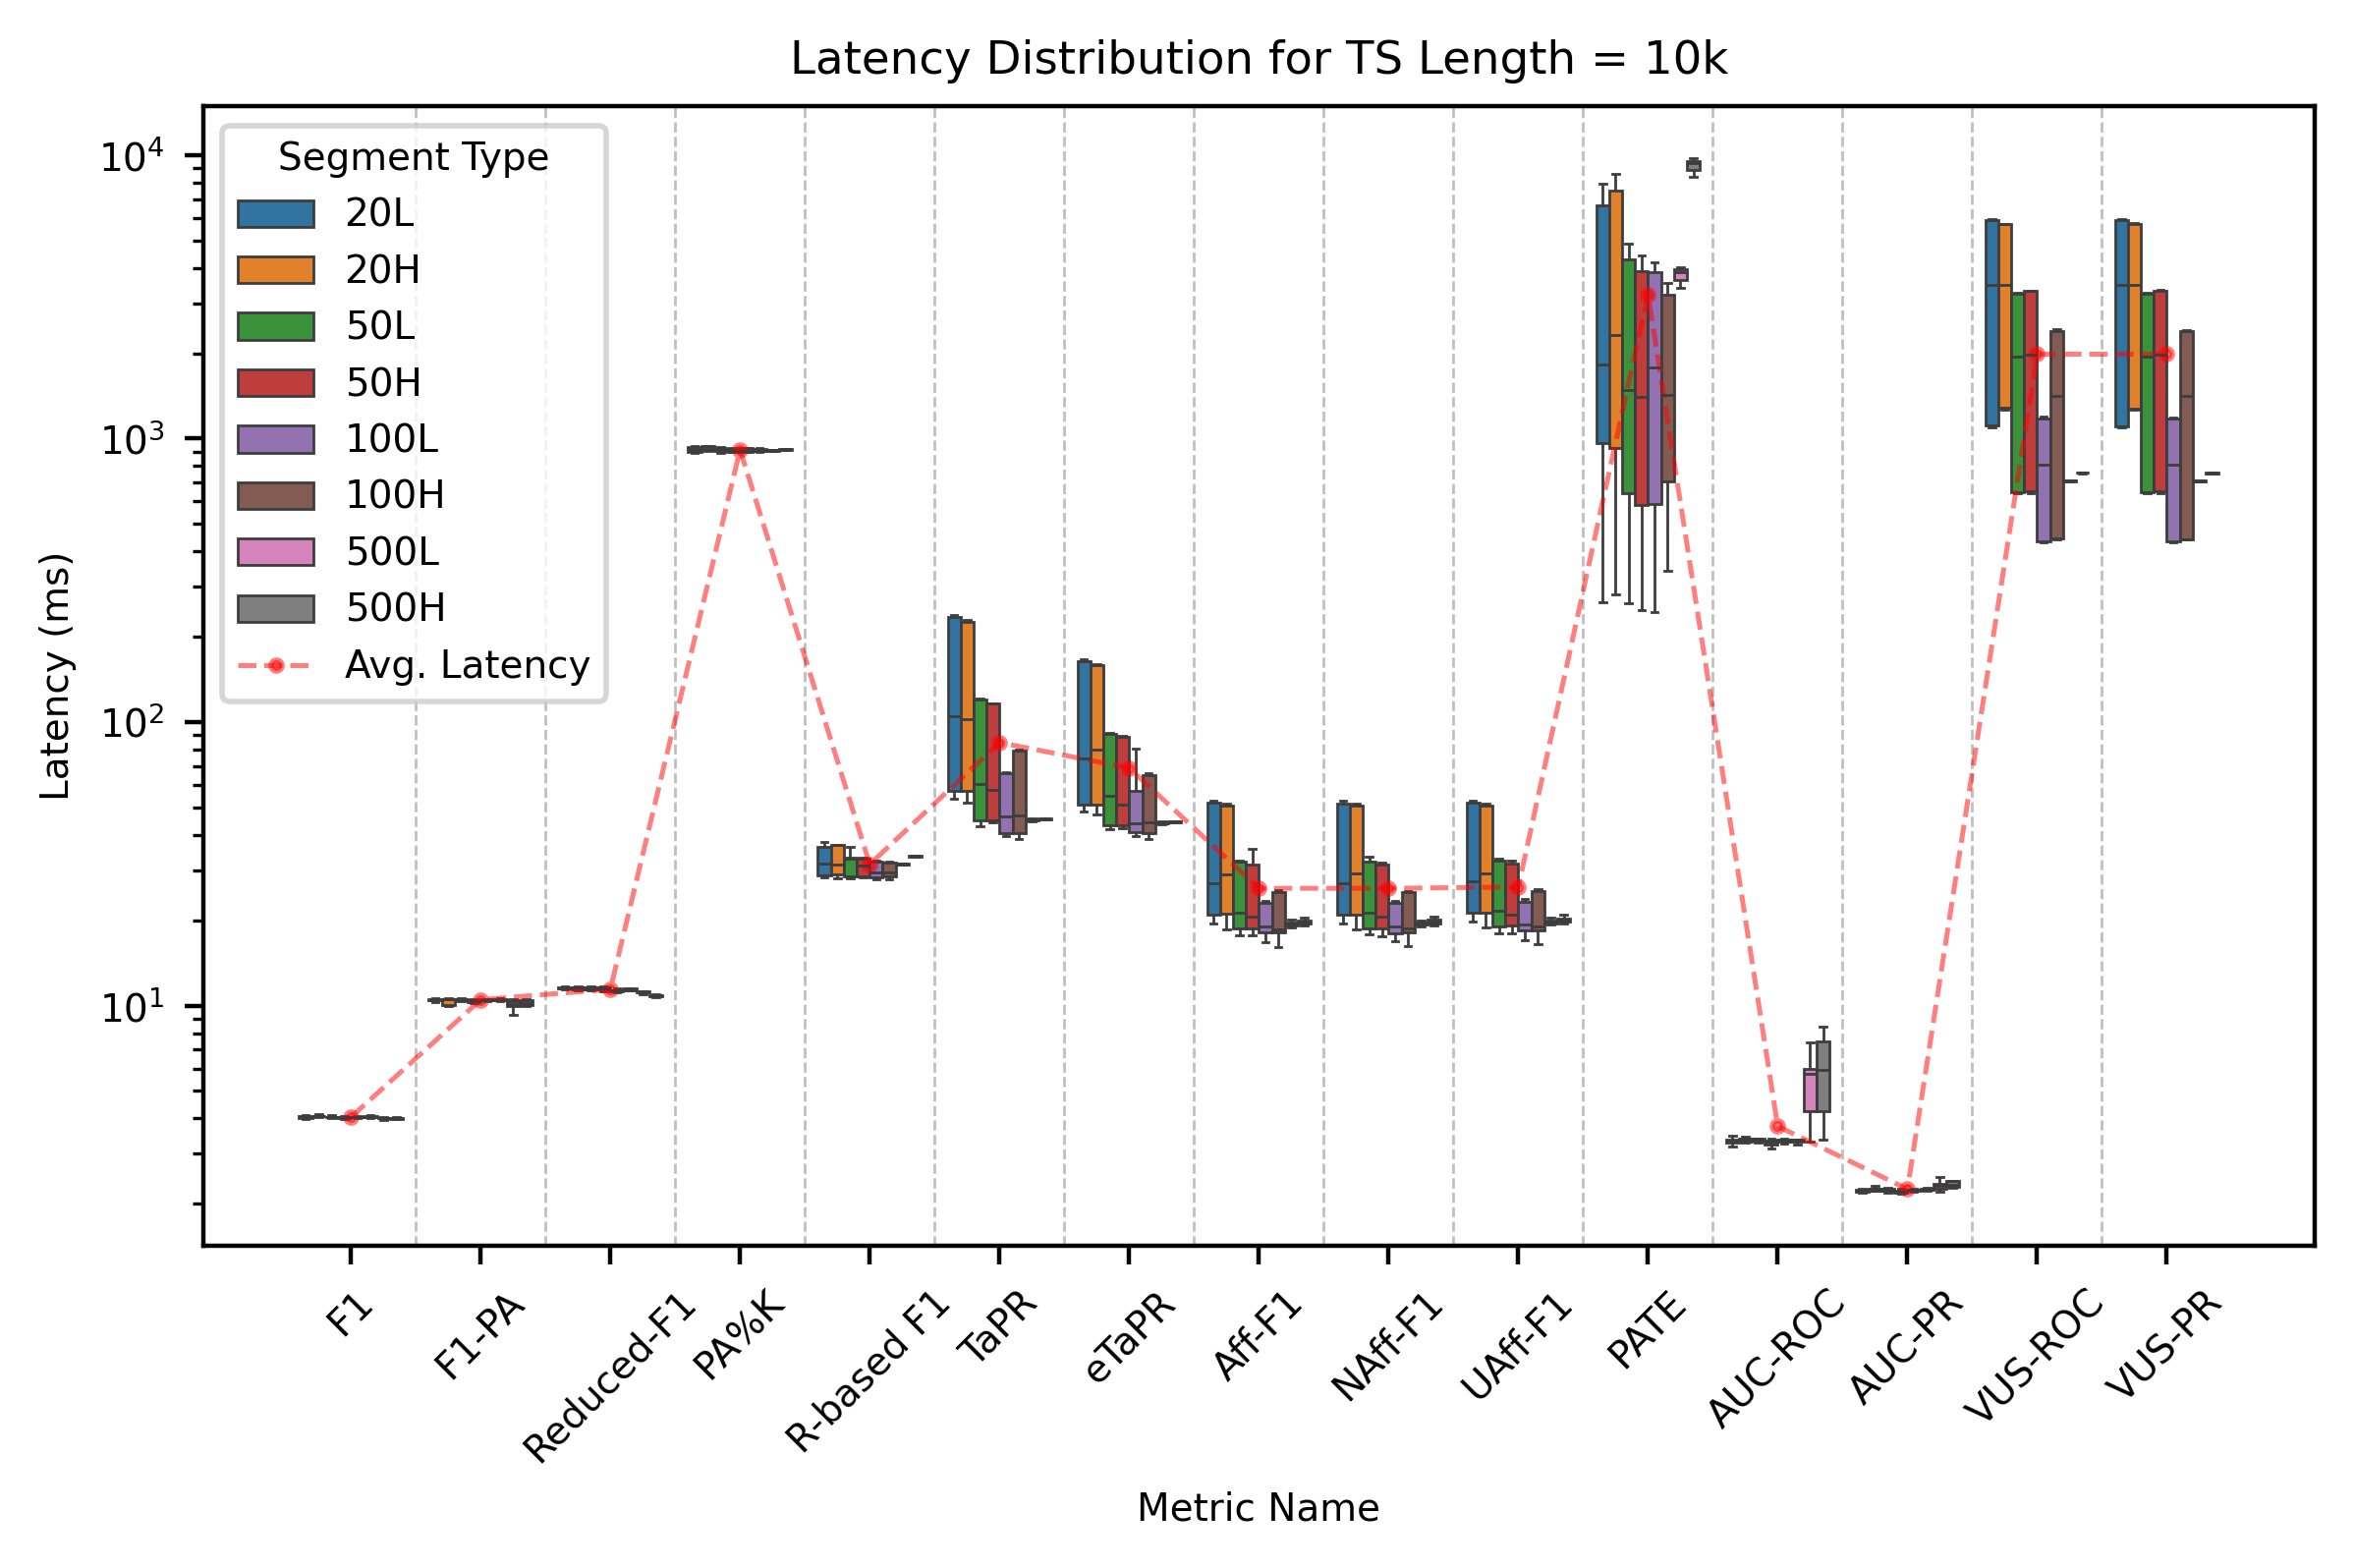

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_latency'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_latency'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    out_pth = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}.csv'
    # 转置
    saving_df = pd.merge(mean_values, std_values, on='metric_name', suffixes=('_mean', '_std'))
    saving_df.columns = ['Metric', 'Avg. Latency', 'Std. Latency']
    saving_df['Avg. Latency per point'] = saving_df['Avg. Latency'] / ts_len
    print(saving_df)
    saving_df.to_csv(out_pth, index=False)
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    mean_values = mean_values.to_numpy()
    plt.plot(mean_values[:, 0], mean_values[:, 1], color='red', marker='o', markersize=2, label='Avg. Latency'
             , linestyle='--', linewidth=0.9,
            #  透明度
                alpha=0.5
             )
    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    
        
    plt.legend(title='Segment Type')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

   metric_name       ratio
0       AUC-PR   70.664060
1      AUC-ROC  122.178196
2       Aff-F1   41.662294
3           F1   61.117841
4        F1-PA   58.797160
5      NAff-F1   40.916830
6         PA%K   24.442642
7         PATE  120.402922
8   R-based F1   22.676747
9   Reduced-F1   41.043175
10        TaPR   44.435588
11     UAff-F1   44.802603
12      VUS-PR    5.732251
13     VUS-ROC    4.884237
14       eTaPR   51.721034


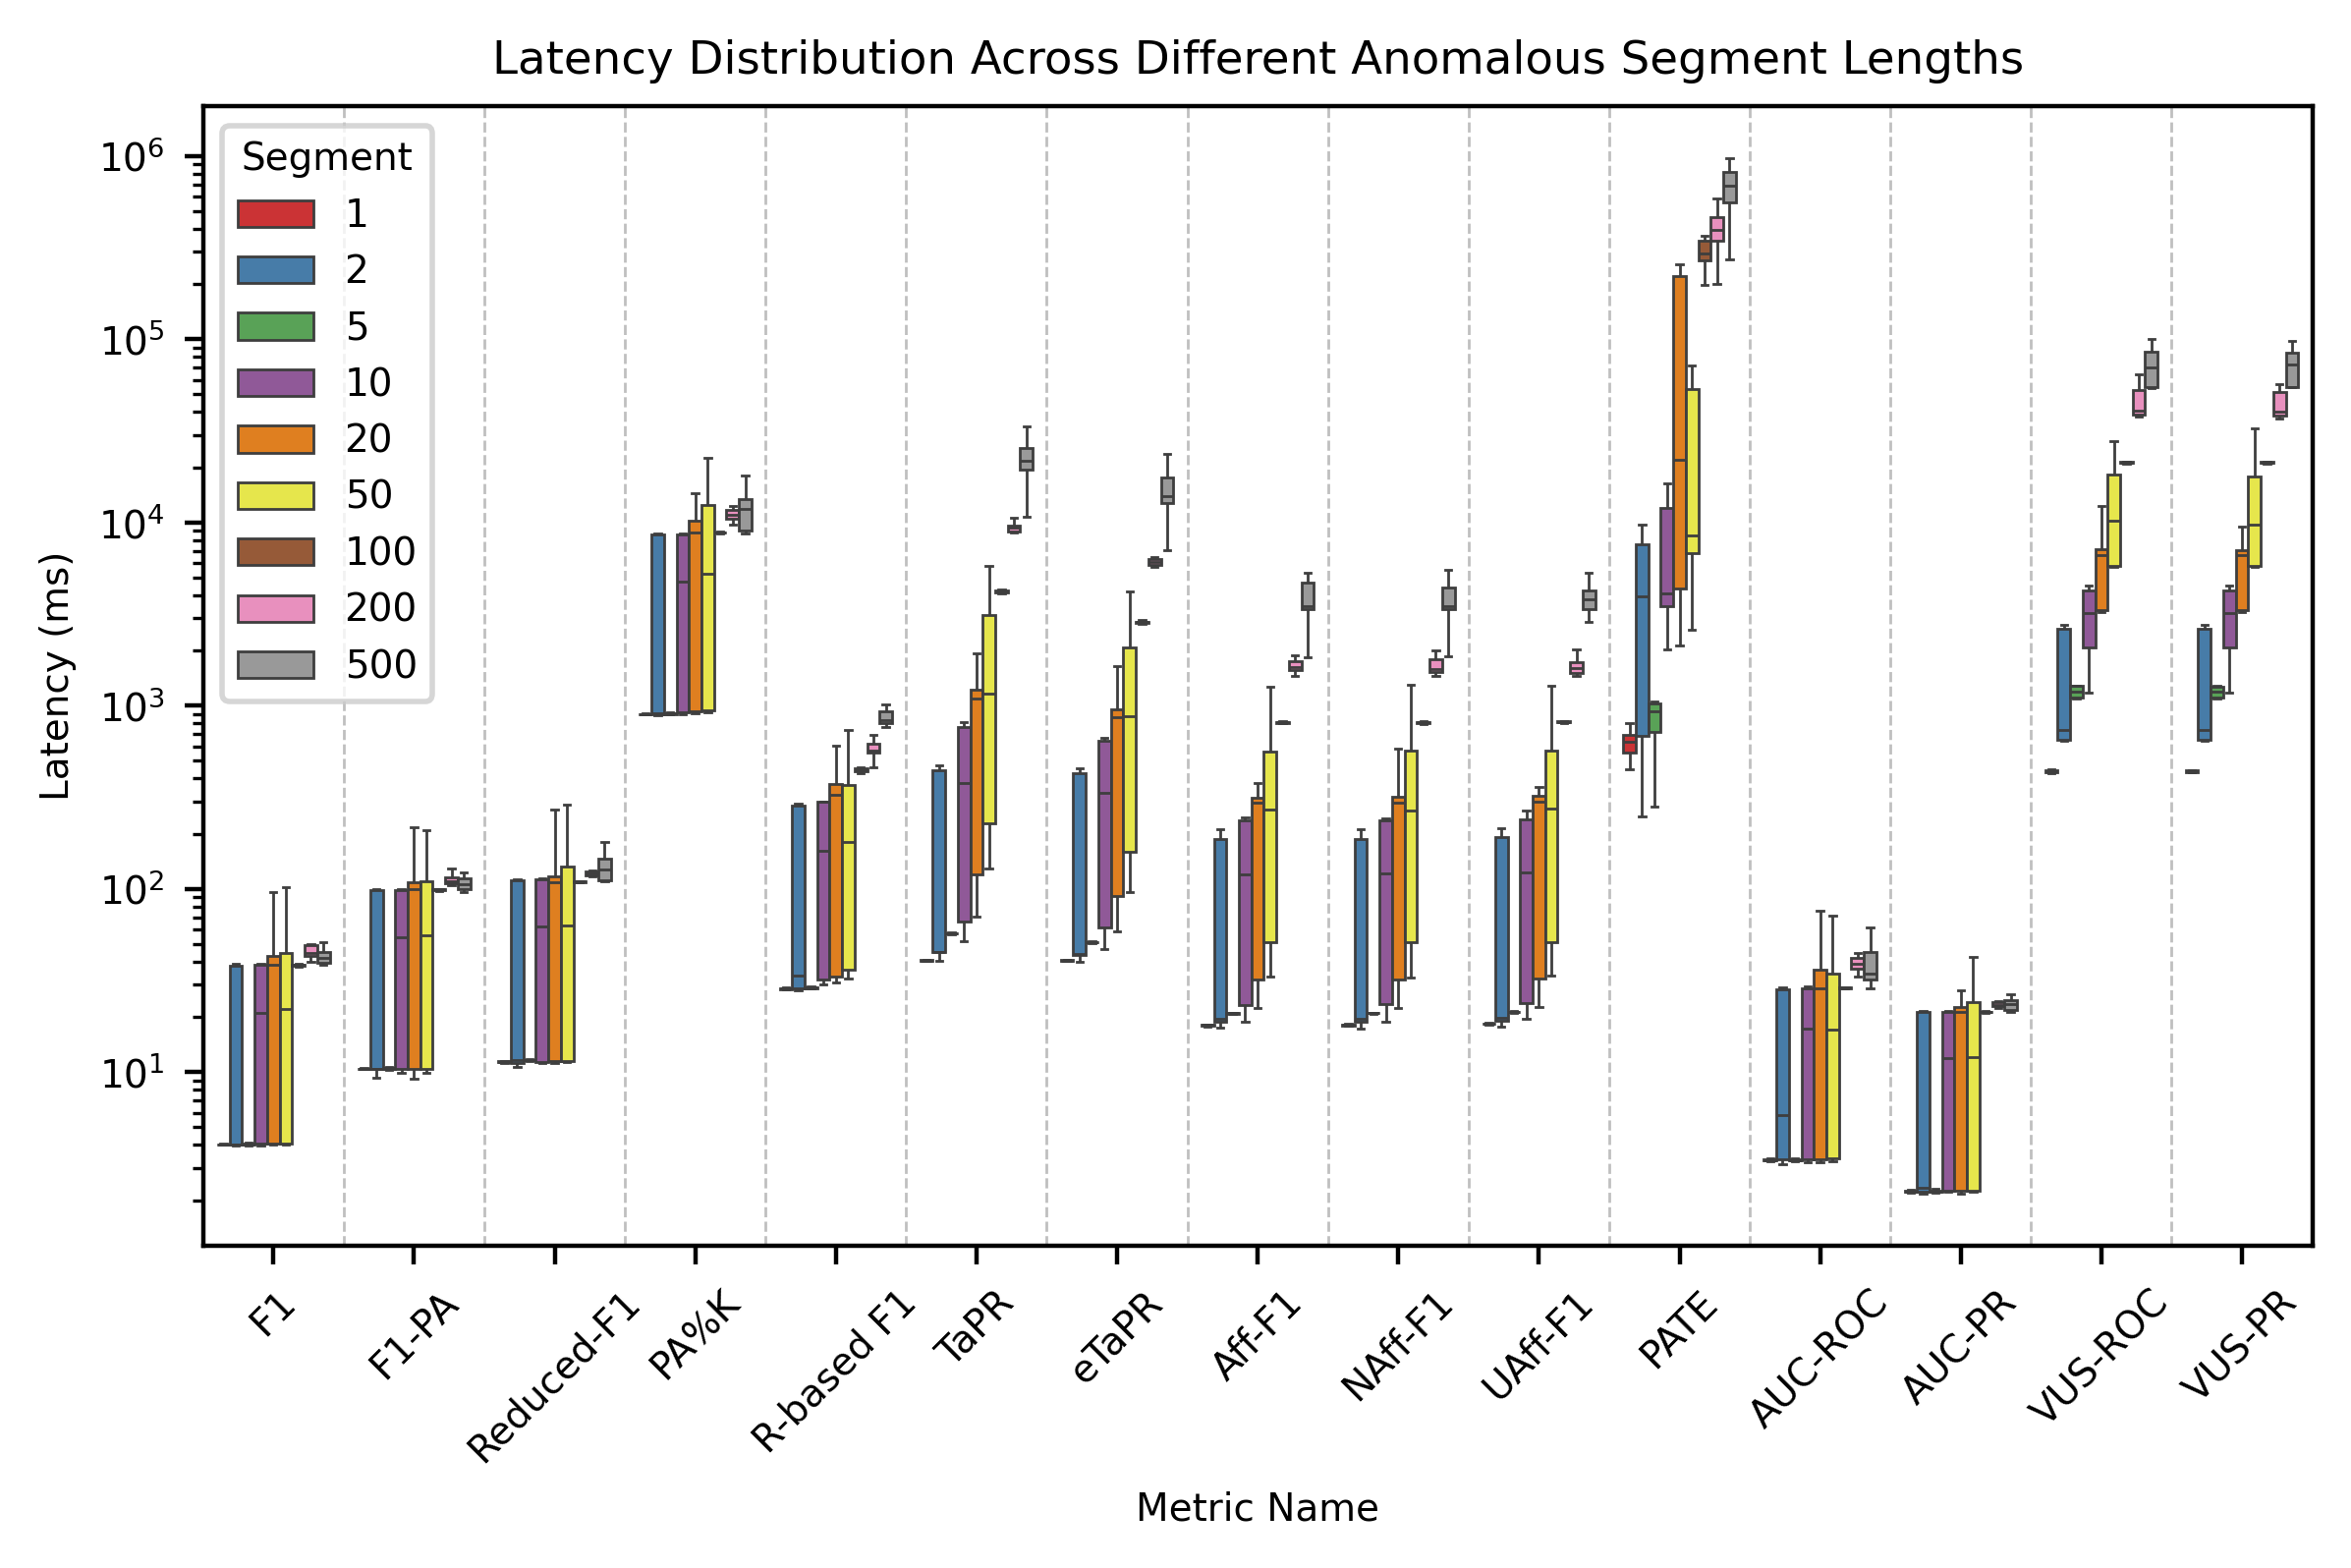

In [8]:
def plot_latency_distribution2(data_new):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort segments numerically
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
                # palette='Set2'  # END: Changed color palette
    min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_latency'].agg(['min', 'max']).reset_index()
    min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    seg_list = df['seg'].unique()
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 

    min_max_ratios_max = min_max_ratios.groupby('metric_name')['ratio'].max().reset_index()
    print(min_max_ratios_max)
    # for i, metric in enumerate(metric_sort):
    #     plt.annotate(
    #         f'Max Ratio: {min_max_ratios_max[min_max_ratios_max["metric_name"] == metric]["ratio"].values[0]:.2f}',
    #         xy=(i, 1.05),  # Adjust the y-coordinate for better visibility
    #         ha='center', va='bottom', fontsize=6, color='black'
    #     )
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Segment')
    plt.title(f'Latency Distribution Across Different Anomalous Segment Lengths')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/ts_len_latency.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments


/tmp/ipykernel_3914103/3599920844.py:27: UserWarning: The palette list has more values (20) than needed (11), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name          mean           std
40           F1    Model70     47.413860     17.027152
39           F1    Model60     52.542667     26.708403
38           F1    Model50     43.666997     13.746027
37           F1    Model40     58.257661     54.475300
36           F1    Model30     41.947339      5.915430
..          ...        ...           ...           ...
139      VUS-PR    Model70  22499.526058  24467.792641
133      VUS-PR   Model100  21404.752645  23259.841387
134      VUS-PR    Model20  23213.130578  26685.246527
132      VUS-PR    Model10  21531.178928  22253.500662
135      VUS-PR    Model30  21750.184043  21365.075907

[165 rows x 4 columns]


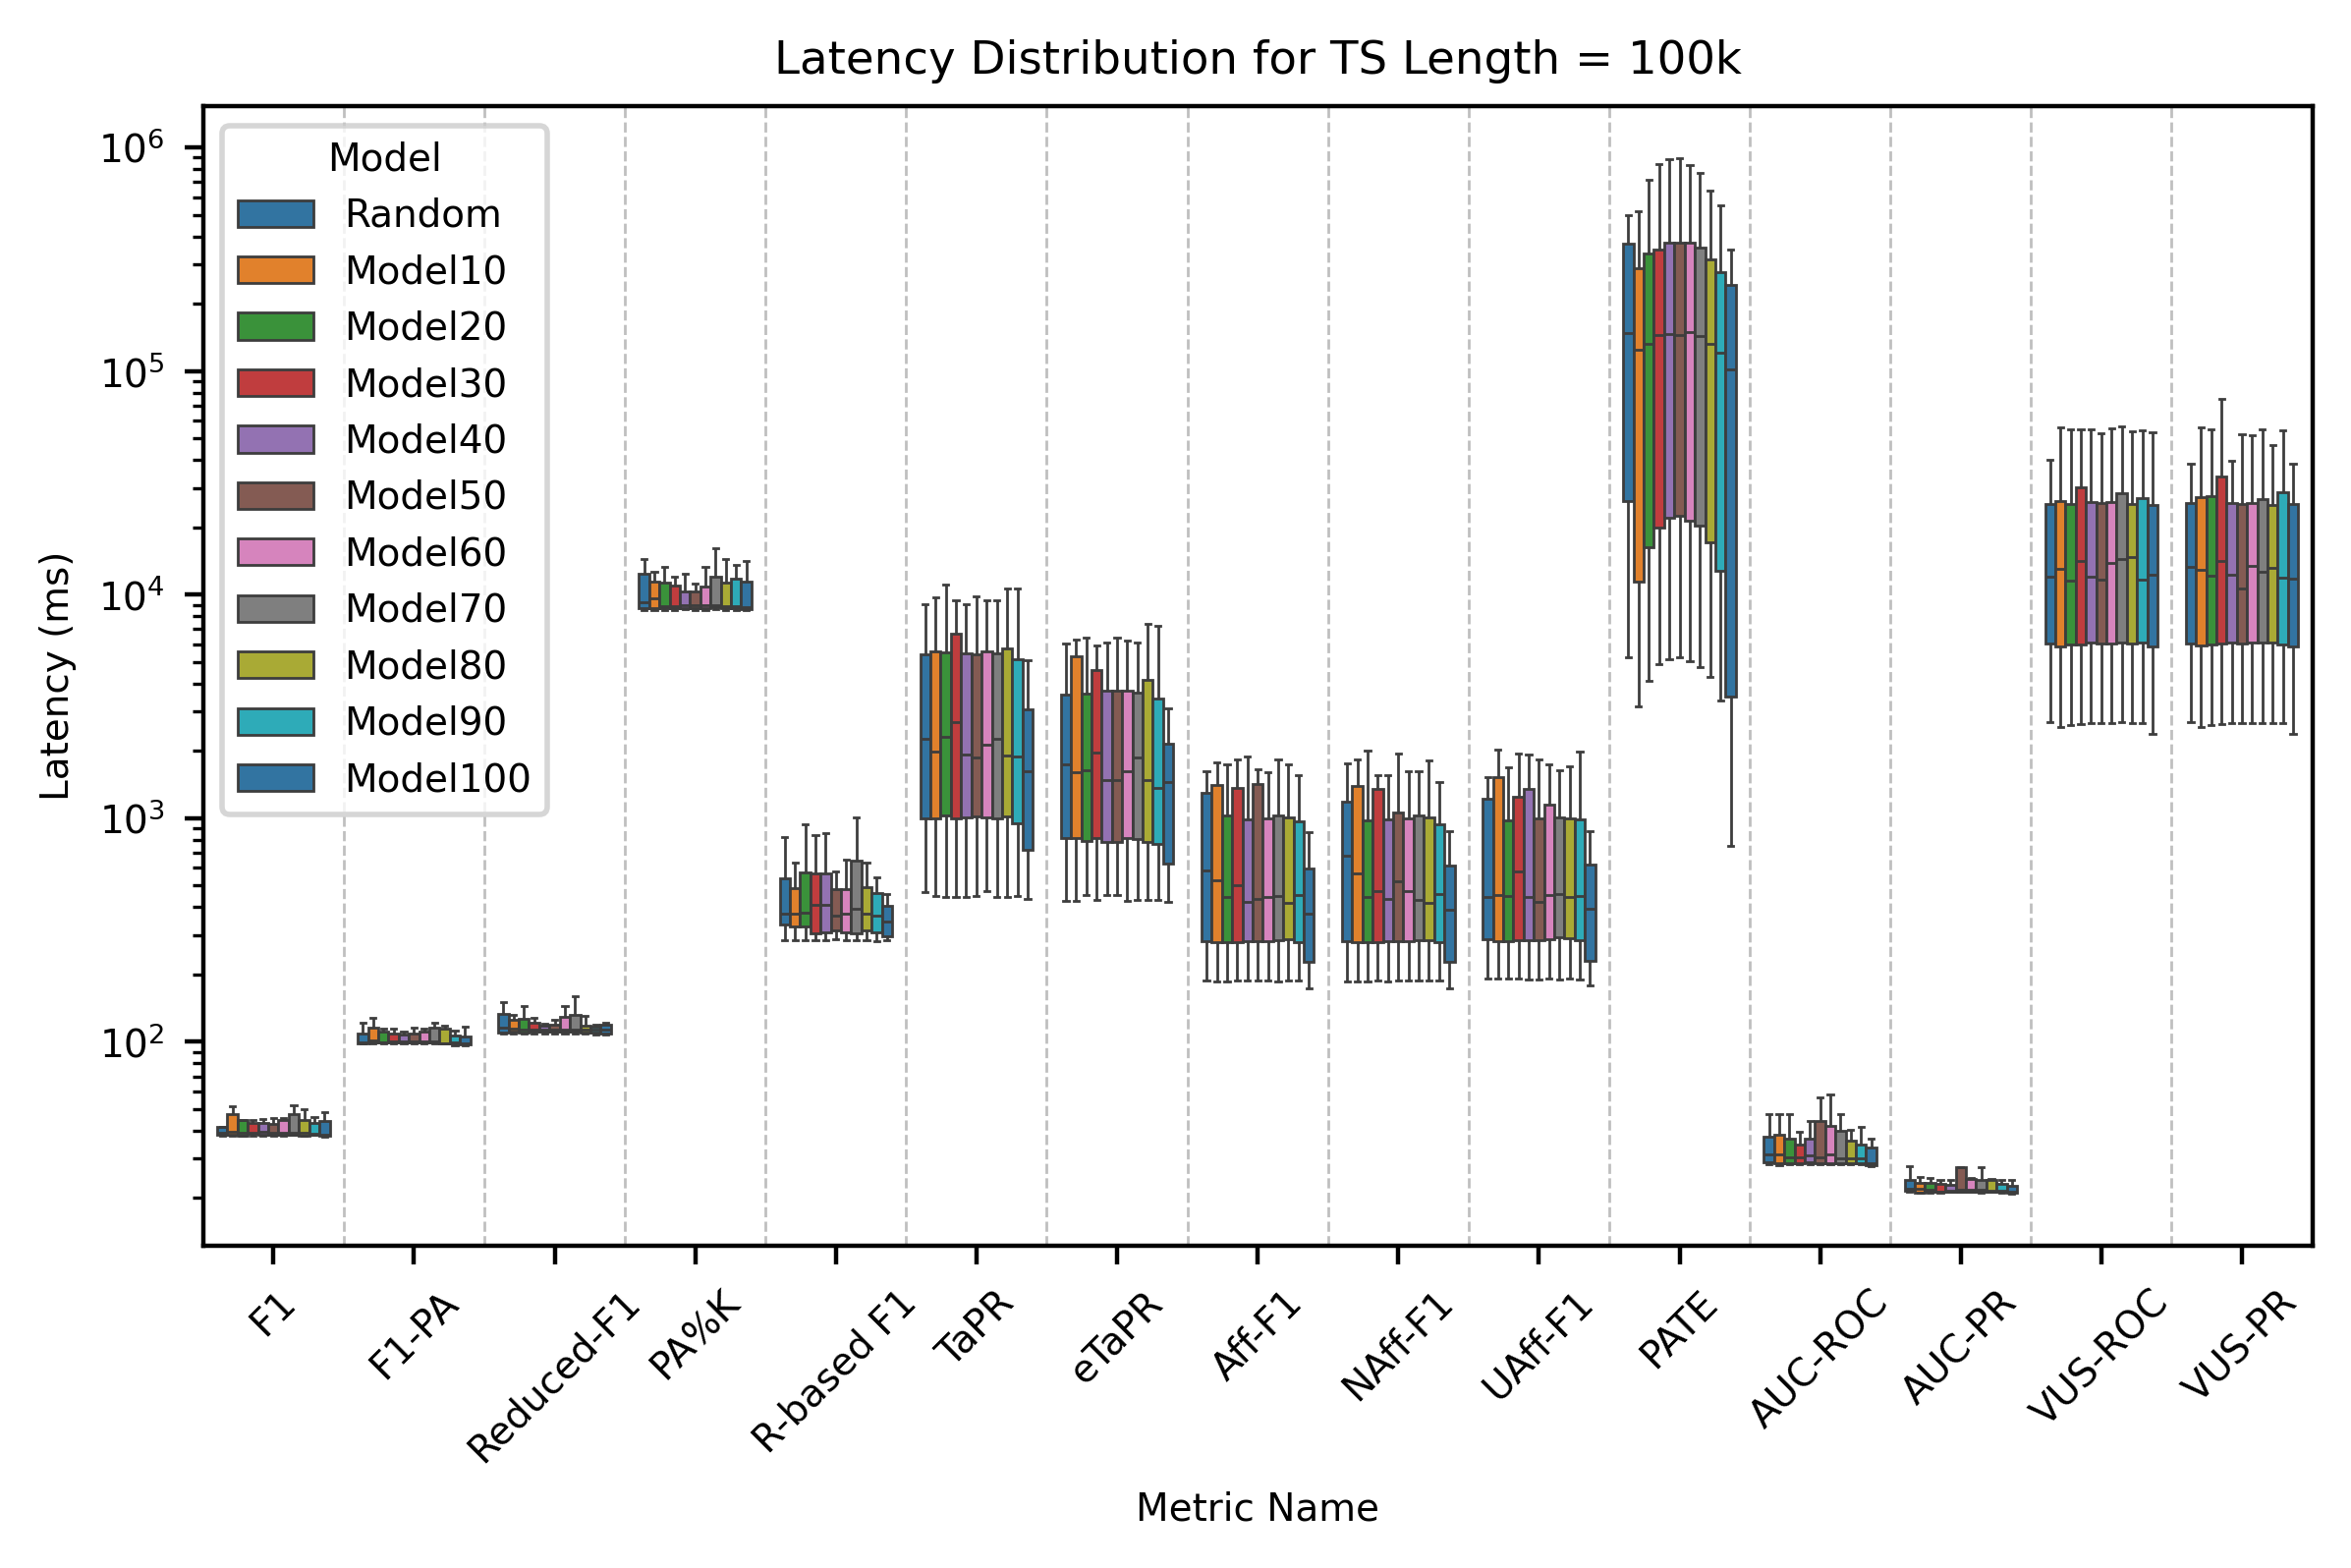

/tmp/ipykernel_3914103/3599920844.py:27: UserWarning: The palette list has more values (20) than needed (11), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name         mean          std
40           F1    Model70     4.046166     0.025650
39           F1    Model60     4.047071     0.043982
38           F1    Model50     4.047410     0.035531
37           F1    Model40     4.044138     0.025218
36           F1    Model30     4.052071     0.070582
..          ...        ...          ...          ...
139      VUS-PR    Model70  1984.149362  1889.647910
133      VUS-PR   Model100  1982.434900  1878.243117
134      VUS-PR    Model20  1989.406303  1887.693750
132      VUS-PR    Model10  1986.413145  1894.187165
135      VUS-PR    Model30  1988.220715  1895.747336

[165 rows x 4 columns]


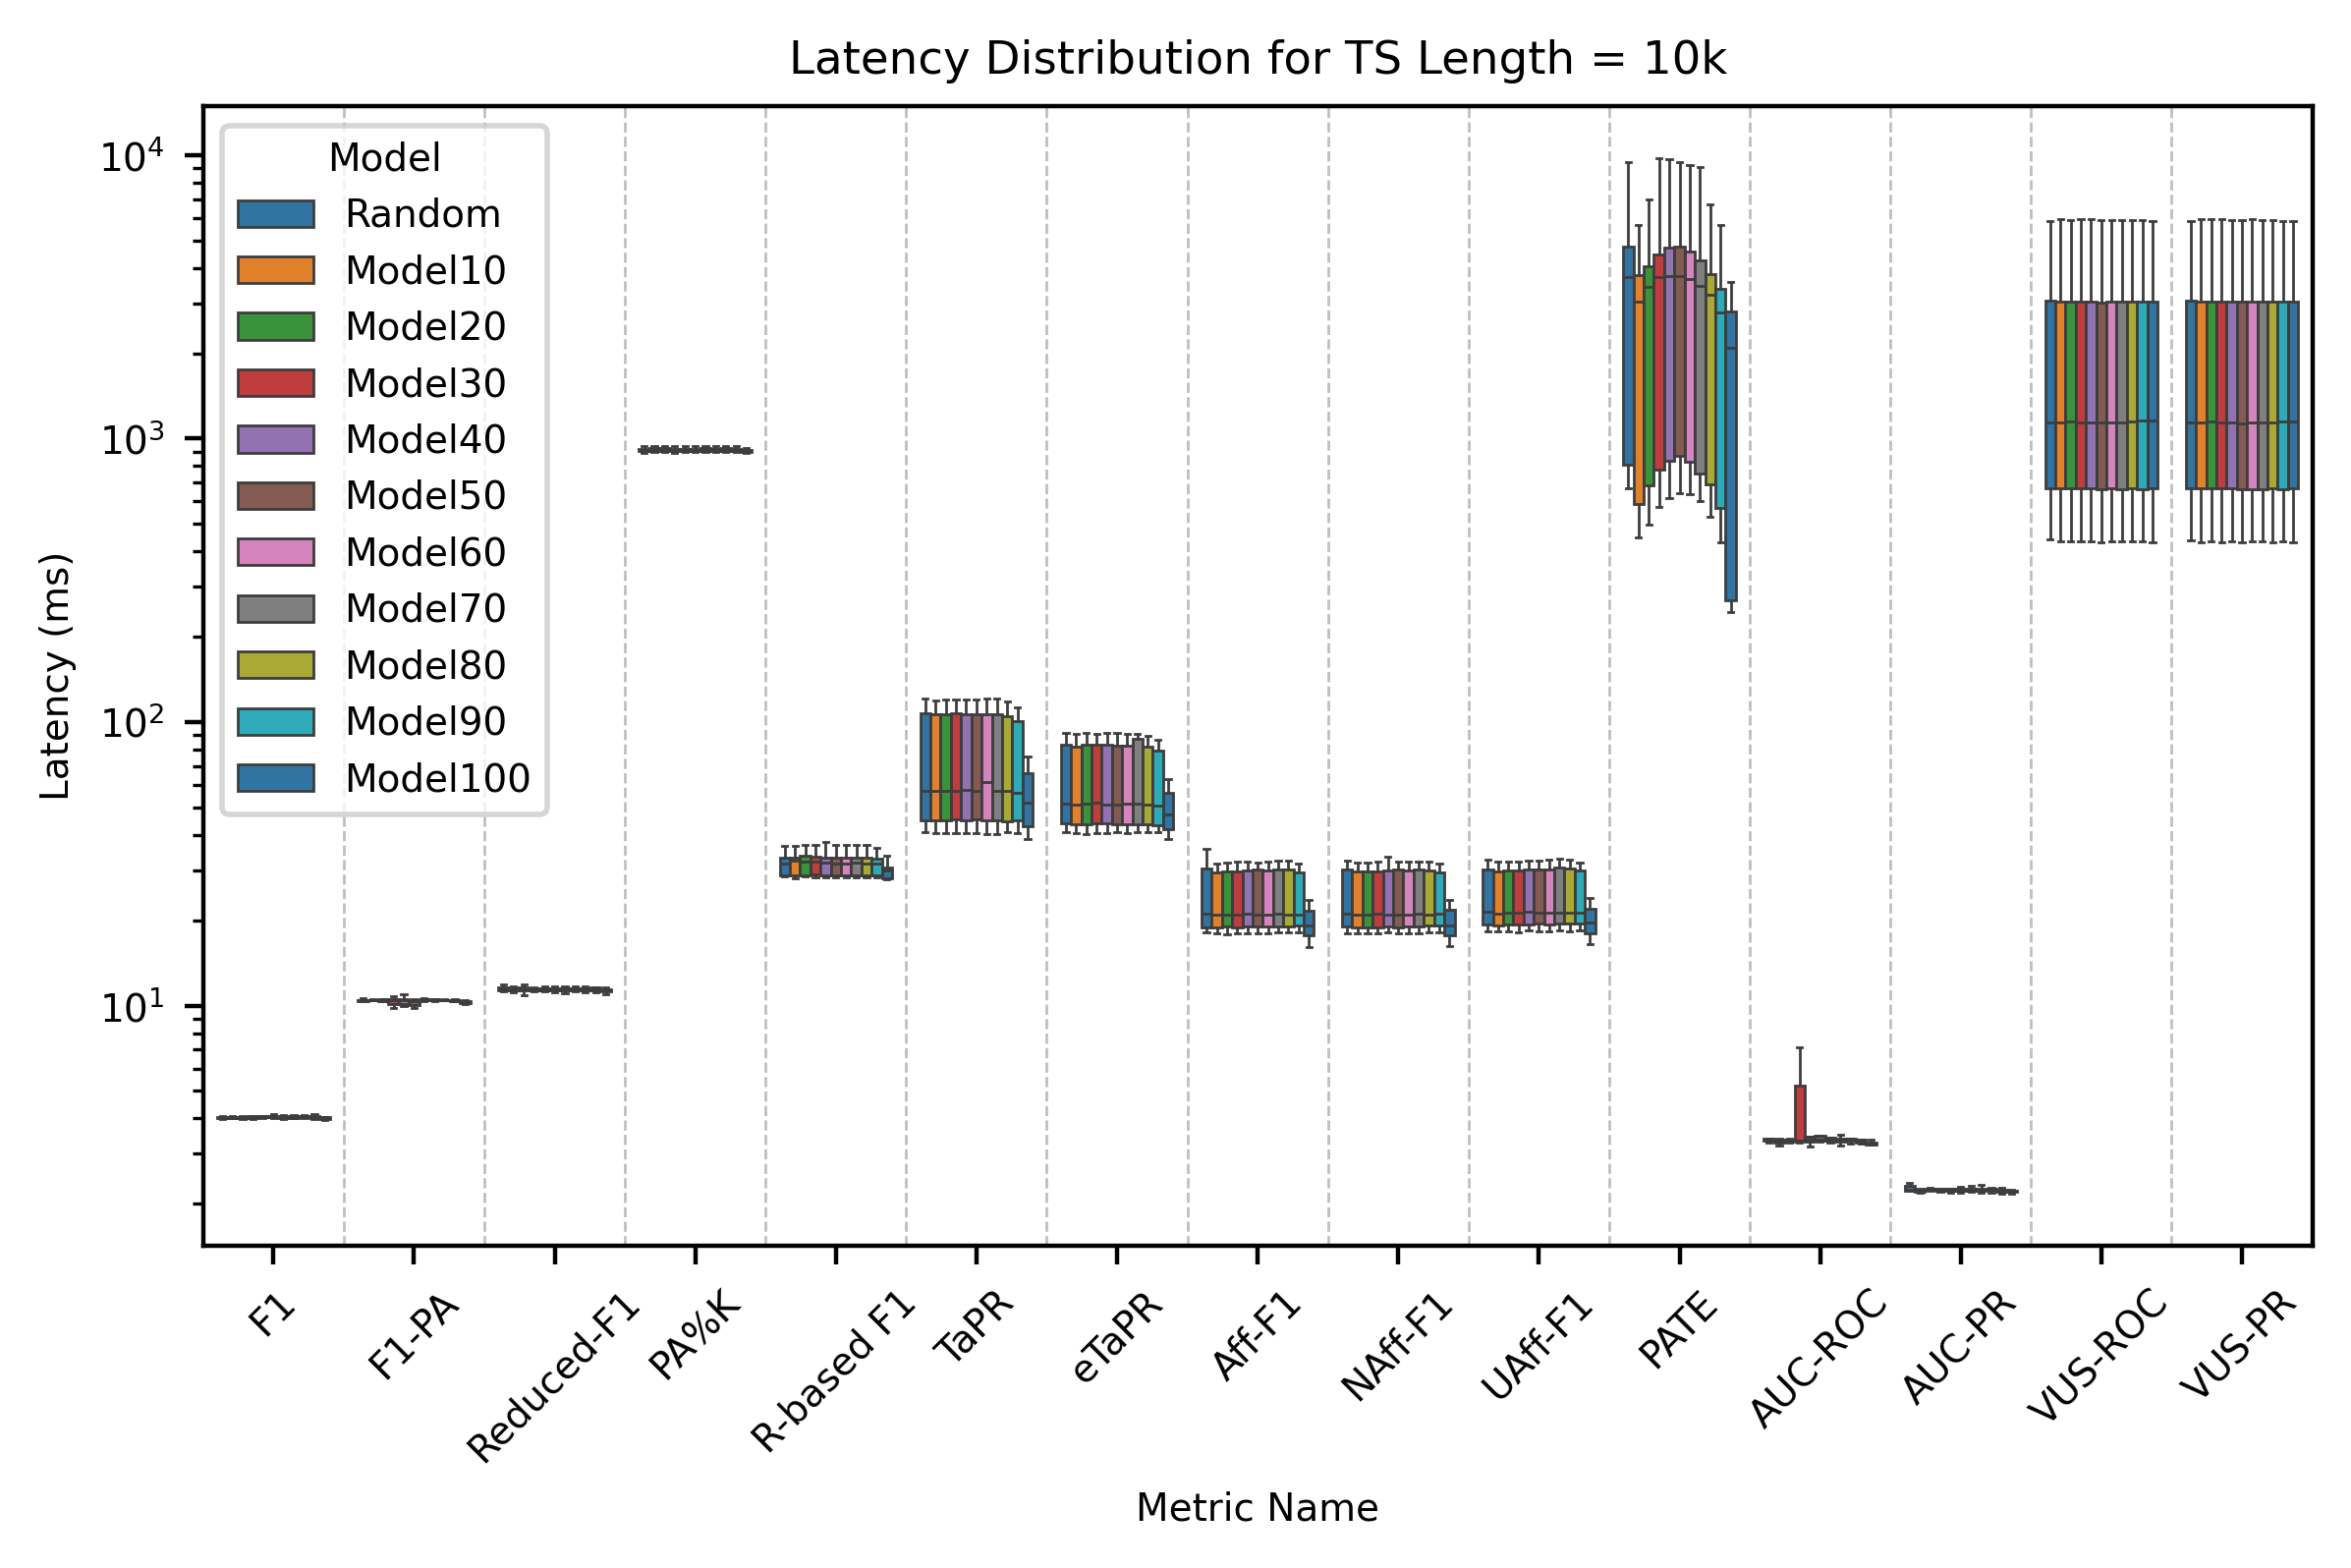

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_latency_distribution3(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        if tmp.startswith('Model'):
            num_part = tmp.split('Model')[-1]
            return int(num_part)
        else:
            return -float('inf')
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_latency'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Model')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000